In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns

print("Libraries Loaded Successfully")

Matplotlib is building the font cache; this may take a moment.


Libraries Loaded Successfully


In [2]:
np.random.seed(42)

n = 1000

H2 = np.random.randint(10, 500, n)
CH4 = np.random.randint(5, 300, n)
C2H2 = np.random.randint(0, 150, n)
C2H4 = np.random.randint(5, 250, n)

fault = []

for h2, ch4, c2h2, c2h4 in zip(H2, CH4, C2H2, C2H4):

    if c2h2 > 100:
        fault.append("Arcing Fault")

    elif h2 > 300:
        fault.append("Partial Discharge")

    elif c2h4 > 150:
        fault.append("Thermal Fault")

    else:
        fault.append("Normal")

df = pd.DataFrame({
    'H2': H2,
    'CH4': CH4,
    'C2H2': C2H2,
    'C2H4': C2H4,
    'Fault': fault
})

df.head()

,H2,CH4,C2H2,C2H4,Fault
0,112,201,48,179,Thermal Fault
1,445,137,119,172,Arcing Fault
2,358,263,43,80,Partial Discharge
3,280,27,55,186,Thermal Fault
4,116,57,110,80,Arcing Fault


In [3]:
print(df.shape)

df.info()

df.describe()

(1000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   H2      1000 non-null   int64 
 1   CH4     1000 non-null   int64 
 2   C2H2    1000 non-null   int64 
 3   C2H4    1000 non-null   int64 
 4   Fault   1000 non-null   object
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


,H2,CH4,C2H2,C2H4
count,1000.000000,1000.000000,1000.000000,1000.00000
mean,255.968000,149.179000,76.964000,125.71100
std,138.728658,87.997025,44.814451,69.95073
min,10.000000,5.000000,0.000000,5.00000
25%,140.000000,71.750000,37.000000,63.00000
50%,251.000000,150.000000,77.000000,127.50000
75%,378.000000,228.000000,118.000000,183.00000
max,499.000000,299.000000,149.000000,249.00000


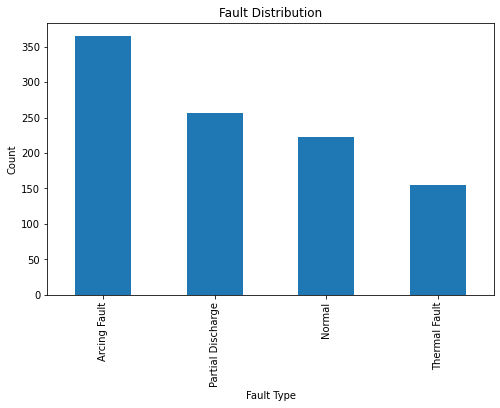

In [4]:
plt.figure(figsize=(8,5))

df['Fault'].value_counts().plot(kind='bar')

plt.title("Fault Distribution")
plt.xlabel("Fault Type")
plt.ylabel("Count")
plt.show()

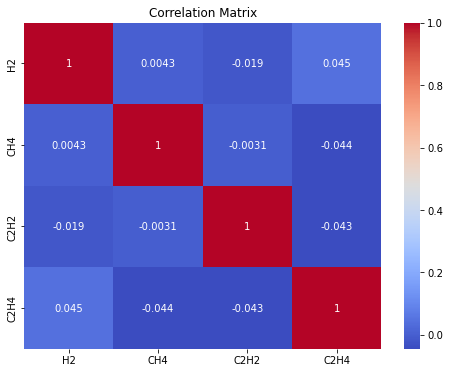

In [5]:
numeric_df = df[['H2','CH4','C2H2','C2H4']]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [6]:
X = df[['H2','CH4','C2H2','C2H4']]

y = df['Fault']

print(X.head())

    H2  CH4  C2H2  C2H4
0  112  201    48   179
1  445  137   119   172
2  358  263    43    80
3  280   27    55   186
4  116   57   110    80


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 800
Testing Samples: 200


In [9]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed")


Model Training Completed


In [10]:
y_pred = model.predict(X_test)

print(y_pred[:10])

['Arcing Fault' 'Partial Discharge' 'Normal' 'Arcing Fault' 'Arcing Fault'
 'Normal' 'Arcing Fault' 'Partial Discharge' 'Thermal Fault'
 'Thermal Fault']


In [11]:
print(classification_report(y_test, y_pred))

                   precision    recall  f1-score   support

     Arcing Fault       1.00      1.00      1.00        76
           Normal       1.00      1.00      1.00        45
Partial Discharge       1.00      1.00      1.00        36
    Thermal Fault       1.00      1.00      1.00        43

         accuracy                           1.00       200
        macro avg       1.00      1.00      1.00       200
     weighted avg       1.00      1.00      1.00       200



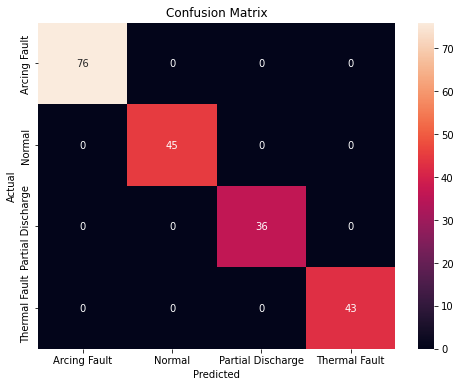

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

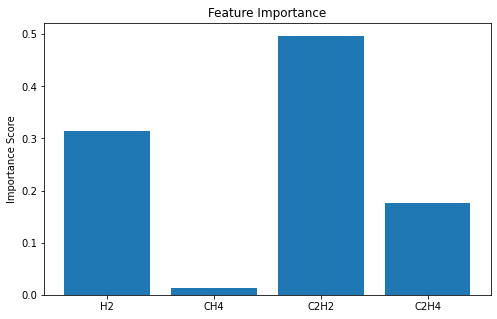

In [13]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.bar(features, importance)

plt.title("Feature Importance")
plt.ylabel("Importance Score")

plt.show()

In [14]:
new_data = pd.DataFrame({
    'H2':[350],
    'CH4':[120],
    'C2H2':[20],
    'C2H4':[80]
})

prediction = model.predict(new_data)

print("Predicted Fault:")
print(prediction[0])


Predicted Fault:
Partial Discharge


In [15]:
h2 = float(input("Enter H2 Value: "))
ch4 = float(input("Enter CH4 Value: "))
c2h2 = float(input("Enter C2H2 Value: "))
c2h4 = float(input("Enter C2H4 Value: "))

sample = pd.DataFrame({
    'H2':[h2],
    'CH4':[ch4],
    'C2H2':[c2h2],
    'C2H4':[c2h4]
})

result = model.predict(sample)

print("\nTransformer Condition:")
print(result[0])

Enter H2 Value:  12
Enter CH4 Value:  24
Enter C2H2 Value:  26
Enter C2H4 Value:  78



Transformer Condition:
Normal


In [17]:
pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.
